# AI-Generated Review Detection — DistilBERT Component

### What this notebook does
1. Loads the train/validation/test splits.
2. Performs exploratory data analysis (EDA) focused on confounds relevant to
   the modelling decisions (class balance, review length, n-gram leakage).
3. Fine-tunes DistilBERT and reports an **in-distribution** result with
   three-seed replication.
4. Tests **cross-domain generalization** via Leave-One-Category-Out (LOCO).
5. Diagnoses *why* performance varies (training-set size vs. domain shift) and
   runs a **length-controlled robustness check**.
6. Provides error analysis (confusion matrices + qualitative inspection).


## 0. Environment setup and reproducibility

In [1]:
# --- Imports ---
# Grouped: stdlib, scientific stack, HuggingFace, scikit-learn.
import os, gc, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
from transformers.utils import logging
logging.disable_progress_bar()

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, classification_report,
)

import datasets
datasets.disable_progress_bars()

In [2]:
# --- Library versions ---
import transformers, datasets, sklearn
print("python       :", os.sys.version.split()[0])
print("torch        :", torch.__version__)
print("transformers :", transformers.__version__)
print("datasets     :", datasets.__version__)
print("scikit-learn :", sklearn.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))

python       : 3.11.0
torch        : 2.6.0+cu124
transformers : 5.8.1
datasets     : 4.8.5
scikit-learn : 1.8.0
CUDA available: True
GPU          : NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
# --- Global reproducibility ---
# Ensure the same single fixed seed is used everywhere.
GLOBAL_SEED = 42

def set_all_seeds(seed: int) -> None:
    """Re-seed every random number generator that can influence training.
    Called at the start of each training run so that (a) results are
    reproducible and (b) multi-seed experiments are genuinely different runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_all_seeds(GLOBAL_SEED)

In [4]:
# --- Paths and project constants ---
# Local setup (VS Code). Paths are relative to the project root.
PROJECT_ROOT = Path.cwd()                     # current working directory
DATA_DIR     = PROJECT_ROOT / "data"          # the three CSVs live here
RESULTS_DIR  = PROJECT_ROOT / "results"       # tables and figures for the paper
MODELS_DIR   = PROJECT_ROOT / "models"        # model checkpoints
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# --- Model and training hyperparameters ---
MODEL_NAME = "distilbert-base-uncased"

# Hyperparameters are held constant across every experiment in this notebook to make it comparable.
LEARNING_RATE = 2e-5
EPOCHS        = 3
TRAIN_BATCH   = 16
EVAL_BATCH    = 32
WEIGHT_DECAY  = 0.01

# MAX_LEN is justified empirically in the EDA section below (it must cover the vast majority of reviews; see the length analysis).
MAX_LEN = 128

# Seeds for the multi-seed in-distribution headline experiment.
SEEDS = [42, 1337, 2024]

## 1. Data loading and integrity checks

The three splits were created **once** by the team and are treated as frozen.
This notebook never re-splits the data, so the DistilBERT results remain
directly comparable to the other team members' models.

In [5]:
# --- Load the frozen splits ---
# sep=';' because the shared CSVs are semicolon-delimited.
DATA_DIR = Path("Data")
df_train = pd.read_csv(DATA_DIR / "train.csv",      sep=";")
df_val   = pd.read_csv(DATA_DIR / "validation.csv", sep=";")
df_test  = pd.read_csv(DATA_DIR / "test.csv",       sep=";")

for name, df in [("train", df_train), ("validation", df_val), ("test", df_test)]:
    print(f"{name:12s}: {df.shape[0]:5d} rows, {df.shape[1]} columns")
print("\ncolumns:", df_train.columns.tolist())

train       :  7000 rows, 5 columns
validation  :  1500 rows, 5 columns
test        :  1500 rows, 5 columns

columns: ['rating', 'title', 'text', 'category', 'ai_generated']


In [6]:
# --- Integrity checks ---
# Catch silent data problems (missing text, unexpected labels, NaNs) before training.
for name, df in [("train", df_train), ("validation", df_val), ("test", df_test)]:
    n_missing_text  = df["text"].isna().sum()
    n_empty_text    = (df["text"].astype(str).str.strip() == "").sum()
    label_values    = sorted(df["ai_generated"].dropna().unique().tolist())
    print(f"{name:12s}: missing text={n_missing_text}, empty text={n_empty_text}, "
          f"label values={label_values}")

# Confirms the data is balanced.
print("\nClass balance (0=human, 1=AI):")
for name, df in [("train", df_train), ("validation", df_val), ("test", df_test)]:
    counts = df["ai_generated"].value_counts().sort_index()
    print(f"  {name:12s}: human={counts.get(0, 0)}, ai={counts.get(1, 0)}")

train       : missing text=0, empty text=0, label values=[0, 1]
validation  : missing text=0, empty text=0, label values=[0, 1]
test        : missing text=0, empty text=0, label values=[0, 1]

Class balance (0=human, 1=AI):
  train       : human=3500, ai=3500
  validation  : human=750, ai=750
  test        : human=750, ai=750


## 2. Exploratory Data Analysis

The EDA deliberately targets **confounds that could undermine the modelling
conclusions**, rather than generic descriptive statistics:

- **Category distribution** — needed to interpret the LOCO experiment.
- **Within-category label balance** — an imbalance here causes *prior shift*
  in the cross-domain results.
- **Review length** — a systematic length difference between classes would let
  the model "cheat" by learning a length cut-off instead of writing style.
- **N-gram leakage** — checks whether one class is dominated by generation
  boilerplate.

In [7]:
# --- Category distribution per split ---
for name, df in [("train", df_train), ("validation", df_val), ("test", df_test)]:
    print(f"\n--- Category counts and shares: {name} ---")
    counts = df["category"].value_counts()
    shares = (df["category"].value_counts(normalize=True) * 100).round(1)
    display(pd.DataFrame({"Count": counts, "Share (%)": shares}))


--- Category counts and shares: train ---


,Count,Share (%)
category,,
Home_and_Kitchen,1523,21.8
Clothing_Shoes_and_Jewelry,1399,20.0
Electronics,812,11.6
Tools_and_Home_Improvement,573,8.2
Health_and_Household,557,8.0
Beauty_and_Personal_Care,493,7.0
Cell_Phones_and_Accessories,477,6.8
Books,435,6.2
Automotive,371,5.3



--- Category counts and shares: validation ---


,Count,Share (%)
category,,
Home_and_Kitchen,331,22.1
Clothing_Shoes_and_Jewelry,303,20.2
Electronics,194,12.9
Health_and_Household,136,9.1
Tools_and_Home_Improvement,115,7.7
Cell_Phones_and_Accessories,102,6.8
Beauty_and_Personal_Care,101,6.7
Kindle_Store,78,5.2
Automotive,72,4.8



--- Category counts and shares: test ---


,Count,Share (%)
category,,
Home_and_Kitchen,312,20.8
Clothing_Shoes_and_Jewelry,296,19.7
Electronics,213,14.2
Health_and_Household,121,8.1
Tools_and_Home_Improvement,110,7.3
Cell_Phones_and_Accessories,104,6.9
Beauty_and_Personal_Care,101,6.7
Kindle_Store,86,5.7
Automotive,79,5.3


In [8]:
# --- Within-category label balance (train) ---
crosstab = pd.crosstab(df_train["category"], df_train["ai_generated"])
crosstab.columns = ["human (0)", "ai (1)"]
crosstab["% AI"] = (crosstab["ai (1)"] /
                    (crosstab["human (0)"] + crosstab["ai (1)"]) * 100).round(1)
display(crosstab.sort_values("% AI"))

,human (0),ai (1),% AI
category,,,
Automotive,235,136,36.7
Electronics,467,345,42.5
Tools_and_Home_Improvement,317,256,44.7
Home_and_Kitchen,801,722,47.4
Health_and_Household,286,271,48.7
Cell_Phones_and_Accessories,234,243,50.9
Beauty_and_Personal_Care,240,253,51.3
Clothing_Shoes_and_Jewelry,665,734,52.5
Books,141,294,67.6


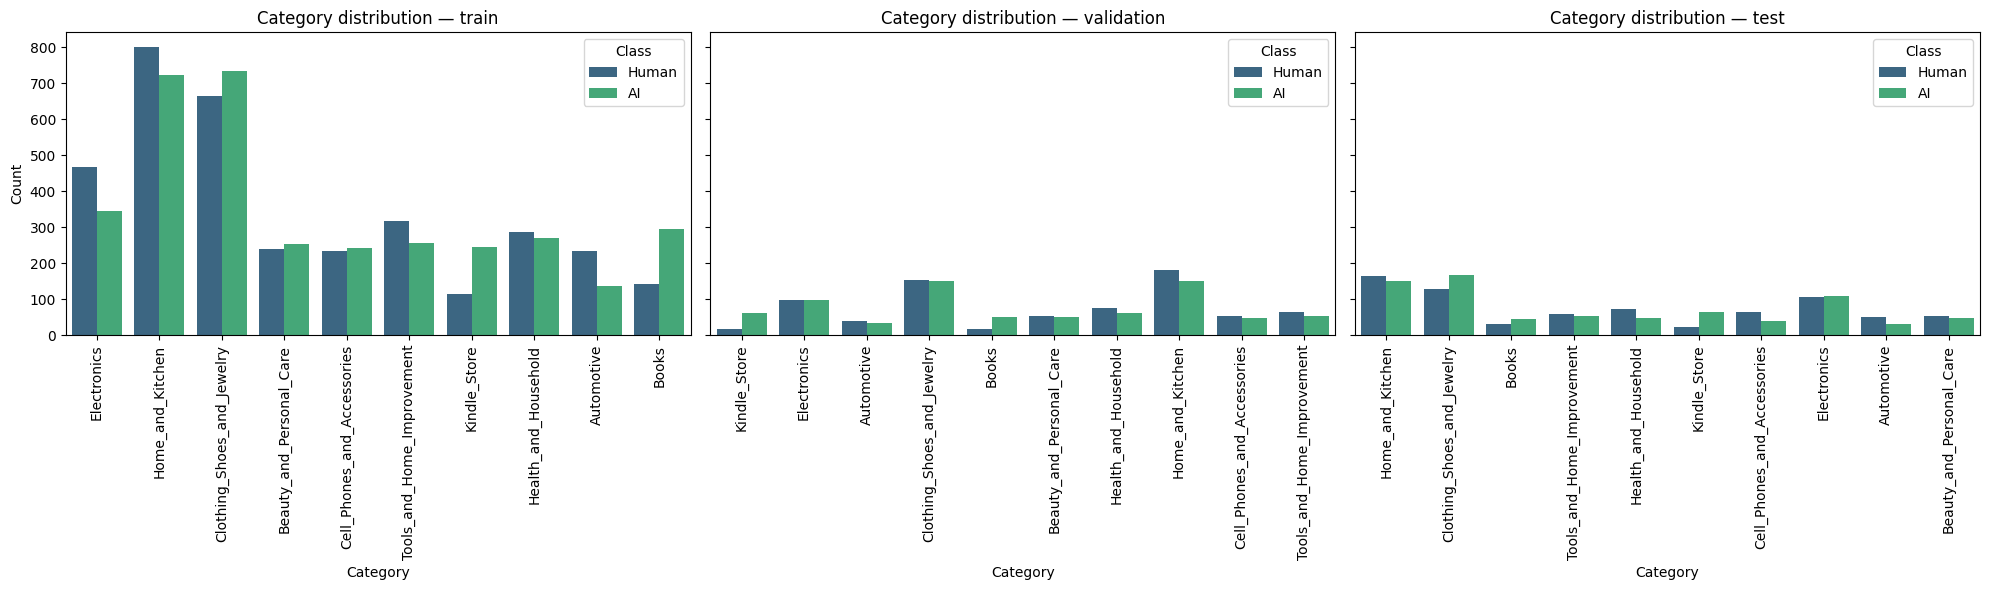

In [9]:
# --- Category distribution plot ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for ax, (name, df) in zip(axes, [("train", df_train), ("validation", df_val),
                                 ("test", df_test)]):
    sns.countplot(data=df, x="category", hue="ai_generated", palette="viridis", ax=ax)
    ax.set_title(f"Category distribution — {name}")
    ax.set_xlabel("Category"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(title="Class", labels=["Human", "AI"])
plt.tight_layout()
plt.show()

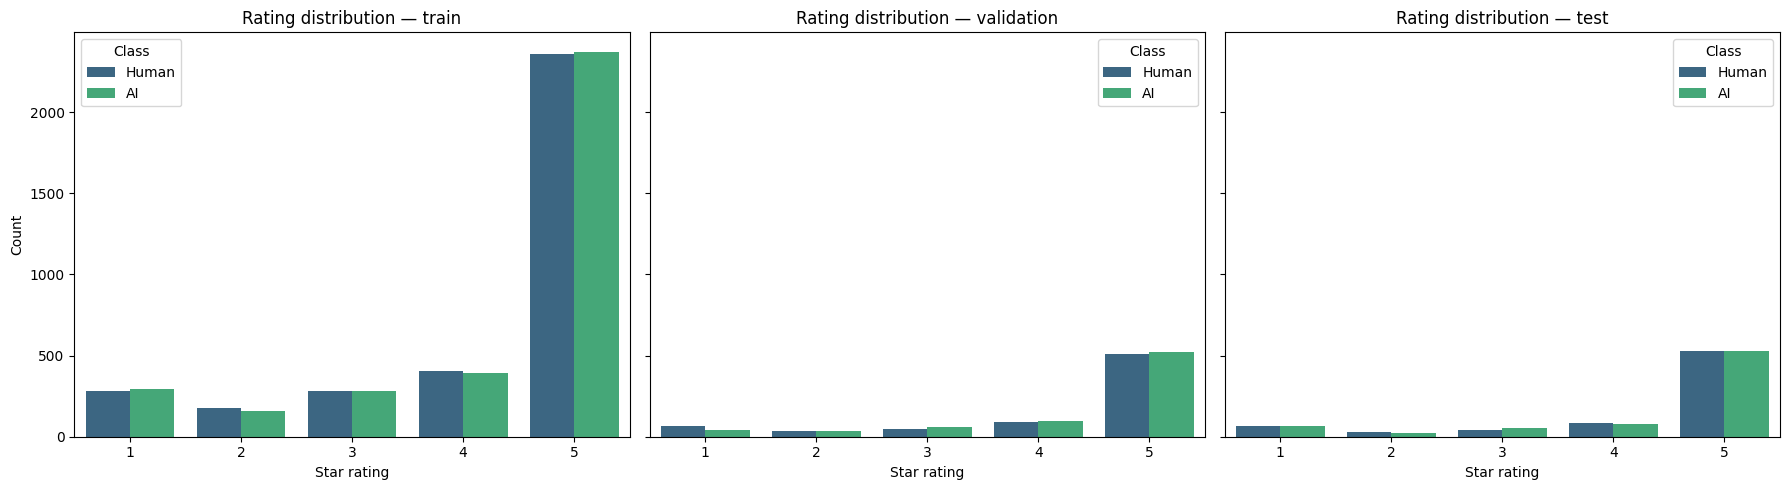

In [10]:
# --- Rating distribution by class ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (name, df) in zip(axes, [("train", df_train), ("validation", df_val),
                                 ("test", df_test)]):
    sns.countplot(data=df, x="rating", hue="ai_generated", palette="viridis",
                  order=sorted(df["rating"].unique()), ax=ax)
    ax.set_title(f"Rating distribution — {name}")
    ax.set_xlabel("Star rating"); ax.set_ylabel("Count")
    ax.legend(title="Class", labels=["Human", "AI"])
plt.tight_layout()
plt.show()

In [11]:
# --- Review length analysis ---
# Length is measured in whitespace-separated tokens.
def add_token_length(df):
    df = df.copy()
    df["n_tokens"] = df["text"].astype(str).str.split().str.len()
    return df

train_len = add_token_length(df_train)

# Numeric summary per class.
print("Token-length summary by class (training set):")
display(train_len.groupby("ai_generated")["n_tokens"].describe().round(1))

# 95th percentile informs the MAX_LEN choice.
p95 = train_len["n_tokens"].quantile(0.95)
print(f"\n95th percentile of review length: {p95:.0f} tokens.")

Token-length summary by class (training set):


,count,mean,std,min,25%,50%,75%,max
ai_generated,,,,,,,,
0,3500.0,41.9,59.3,1.0,11.0,24.0,48.0,887.0
1,3500.0,22.2,11.1,1.0,14.0,23.0,29.0,70.0



95th percentile of review length: 92 tokens.


C:\Users\katig\AppData\Local\Temp\ipykernel_23480\3187663452.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_len, x="ai_generated", y="n_tokens", palette="viridis", ax=axes[1])


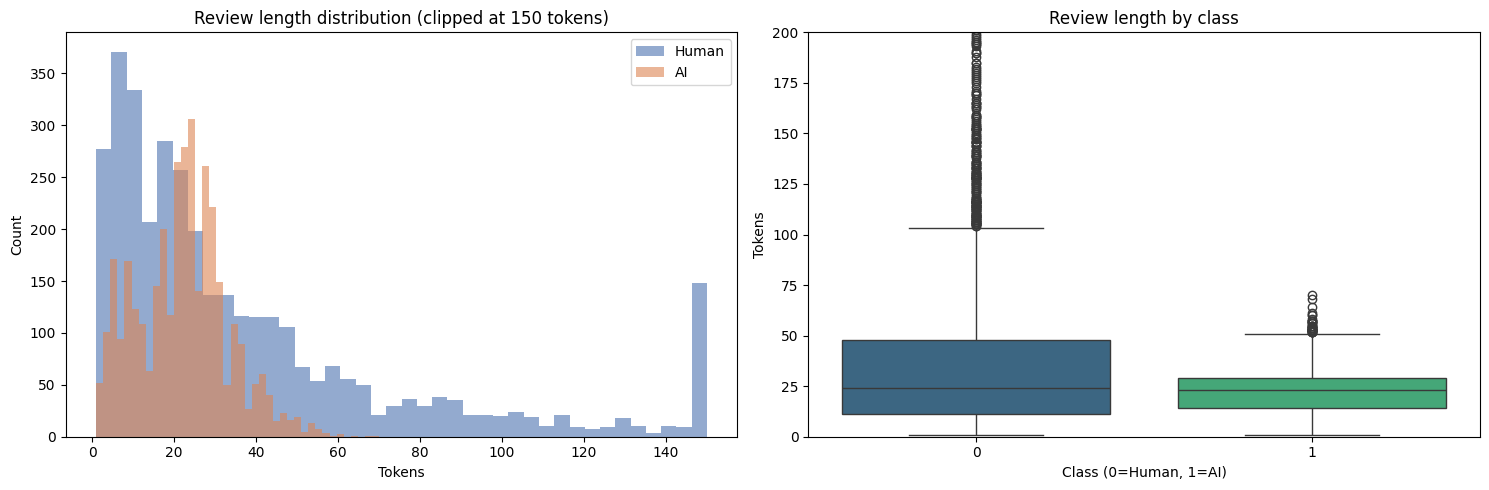

Interpretation: if the AI class has a much narrower length range than the human class, length is a partial confound. This is addressed by the length-controlled robustness check in Section 9.


In [12]:
# --- Length distribution figure ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram (clipped at 150 tokens for readability).
for cls, lab, col in [(0, "Human", "#4C72B0"), (1, "AI", "#DD8452")]:
    sub = train_len.loc[train_len["ai_generated"] == cls, "n_tokens"].clip(upper=150)
    axes[0].hist(sub, bins=40, alpha=0.6, label=lab, color=col)
axes[0].set_title("Review length distribution (clipped at 150 tokens)")
axes[0].set_xlabel("Tokens"); axes[0].set_ylabel("Count"); axes[0].legend()

# Boxplot
sns.boxplot(data=train_len, x="ai_generated", y="n_tokens", palette="viridis", ax=axes[1])
axes[1].set_title("Review length by class")
axes[1].set_xlabel("Class (0=Human, 1=AI)"); axes[1].set_ylabel("Tokens")
axes[1].set_ylim(0, 200)

plt.tight_layout()
plt.show()

#
#
#
print("Interpretation: if the AI class has a much narrower length range than "
      "the human class, length is a partial confound. This is addressed by the "
      "length-controlled robustness check in Section 9.")

In [13]:
# --- N-gram leakage check ---
def top_ngrams_per_class(df, text_col="text", label_col="ai_generated",
                         ngram_range=(1, 3), top_k=25):
    out = {}
    for cls in sorted(df[label_col].unique()):
        texts = df.loc[df[label_col] == cls, text_col].astype(str).tolist()
        vec = CountVectorizer(ngram_range=ngram_range, min_df=5, stop_words="english")
        X = vec.fit_transform(texts)
        counts = X.sum(axis=0).A1
        vocab = vec.get_feature_names_out()
        top = sorted(zip(vocab, counts), key=lambda x: -x[1])[:top_k]
        out[cls] = pd.DataFrame(top, columns=["ngram", "count"])
    return out

ngrams = top_ngrams_per_class(df_train)
print("Top n-grams — HUMAN class (0):")
display(ngrams[0])
print("Top n-grams — AI class (1):")
display(ngrams[1])

Top n-grams — HUMAN class (0):


,ngram,count
0,like,747
1,great,733
2,good,594
3,just,583
4,use,536
5,love,483
6,easy,448
7,really,421
8,nice,400
9,fit,298


Top n-grams — AI class (1):


,ngram,count
0,great,507
1,ve,489
2,bit,376
3,highly,323
4,recommend,319
5,highly recommend,301
6,love,268
7,like,245
8,perfectly,241
9,perfect,230


## 3. Modelling setup

All experiments reuse the same set of helper functions, defined once here.
This guarantees that the in-distribution and cross-domain experiments use an
identical training and evaluation procedure.

In [14]:
# --- Tokenizer ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [15]:
# --- Helper functions ---

def prep_dataset(df: pd.DataFrame) -> Dataset:
    """Convert a dataframe slice into a tokenized HuggingFace Dataset
    containing only the columns the Trainer needs."""
    ds = Dataset.from_pandas(
        df[["text", "ai_generated"]].rename(columns={"ai_generated": "label"}),
        preserve_index=False,
    )
    ds = ds.map(
        lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LEN),
        batched=True,
    )
    # Drop the raw text so the data collator only sees tensors.
    return ds.remove_columns(["text"])


def fresh_model():
    """A new model is created for every training run so no information
    leaks between experiments or LOCO folds."""
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2,
        id2label={0: "human", 1: "ai"}, label2id={"human": 0, "ai": 1},
    )


def compute_metrics(eval_pred):
    """Metrics computed by the Trainer on the validation set each epoch."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.from_numpy(logits), dim=-1)[:, 1].numpy()
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1,
        "macro_precision": p,
        "macro_recall": r,
        "roc_auc": roc_auc_score(labels, probs),
    }


def per_class_metrics(y_true, y_pred, y_prob):
    """Full metric set including per-class precision/recall/F1.
    Per-class metrics are essential for diagnosing prior-shift effects in the
    cross-domain experiment: a symmetric drop indicates genuine domain shift,
    while a one-sided collapse indicates a class-prior artefact."""
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0)
    mp, mr, mf1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": mf1, "macro_precision": mp, "macro_recall": mr,
        "roc_auc": roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float("nan"),
        "precision_human": p[0], "recall_human": r[0], "f1_human": f1[0],
        "precision_ai": p[1], "recall_ai": r[1], "f1_ai": f1[1],
    }


def train_one(train_df, val_df, output_dir, seed=GLOBAL_SEED, epochs=EPOCHS):
    """Fine-tune one DistilBERT model and return the Trainer with the best
    epoch's weights loaded. Used by every experiment in the notebook."""
    set_all_seeds(seed)
    args = TrainingArguments(
        output_dir=str(output_dir),
        num_train_epochs=epochs,
        per_device_train_batch_size=TRAIN_BATCH,
        per_device_eval_batch_size=EVAL_BATCH,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,                 # keep only the best checkpoint
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),     # mixed precision: less memory
        logging_steps=50,
        seed=seed,
        report_to="none",
        disable_tqdm=True,                  # cleaner logs inside loops
    )
    trainer = Trainer(
        model=fresh_model(), args=args,
        train_dataset=prep_dataset(train_df),
        eval_dataset=prep_dataset(val_df),
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )
    trainer.train()
    return trainer


def predict_on_df(trainer, df):
    """Run a trained model on an arbitrary dataframe slice and return the
    full per-class metric set."""
    out = trainer.predict(prep_dataset(df))
    logits = out.predictions
    y_true = out.label_ids
    y_pred = np.argmax(logits, axis=-1)
    y_prob = torch.softmax(torch.from_numpy(logits), dim=-1)[:, 1].numpy()
    return per_class_metrics(y_true, y_pred, y_prob)


def free_memory(*objs):
    """Delete objects and clear the GPU cache between training runs
    (important on memory-constrained GPUs)."""
    for o in objs:
        del o
    gc.collect()
    torch.cuda.empty_cache()

## 4. Experiment 1 — In-distribution detection (headline result)

DistilBERT is trained on df_train, fine-tuned on df_val, and evaluated on the held-out test set. The run is repeated for **three random seeds** and reported as mean ± standard deviation. Three seeds is the minimum used to demonstrate stability in the NLP literature; it is sufficient here because the question is variance of the *in-distribution* estimate, not an exhaustive search.

In [16]:
# --- In-distribution training ---
# Trains three models with different seeds to show robustness of the results.

seed_rows = []
headline_trainer = None

for seed in SEEDS:
    print(f"\n=== Seed {seed} ===")
    t0 = time.time()
    trainer_s = train_one(df_train, df_val,          # original frozen splits
                          MODELS_DIR / f"headline_seed{seed}", seed=seed)
    metrics = predict_on_df(trainer_s, df_test)
    seed_rows.append({"seed": seed, **metrics, "minutes": (time.time() - t0) / 60})

    if seed == SEEDS[0]:
        headline_trainer = trainer_s
    else:
        free_memory(trainer_s)

seed_df = pd.DataFrame(seed_rows)
seed_df.to_csv(RESULTS_DIR / "headline_seed_replicates.csv", index=False)
display(seed_df.round(4))

headline_trainer.save_model(str(MODELS_DIR / "headline_seed42_final"))
tokenizer.save_pretrained(str(MODELS_DIR / "headline_seed42_final"))


=== Seed 42 ===


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.5612', 'grad_norm': '5.167', 'learning_rate': '1.927e-05', 'epoch': '0.1142'}
{'loss': '0.2559', 'grad_norm': '1.982', 'learning_rate': '1.851e-05', 'epoch': '0.2283'}
{'loss': '0.2184', 'grad_norm': '12.1', 'learning_rate': '1.776e-05', 'epoch': '0.3425'}
{'loss': '0.188', 'grad_norm': '13.6', 'learning_rate': '1.7e-05', 'epoch': '0.4566'}
{'loss': '0.1387', 'grad_norm': '0.9676', 'learning_rate': '1.624e-05', 'epoch': '0.5708'}
{'loss': '0.1626', 'grad_norm': '10.1', 'learning_rate': '1.549e-05', 'epoch': '0.6849'}
{'loss': '0.1539', 'grad_norm': '11.17', 'learning_rate': '1.473e-05', 'epoch': '0.7991'}
{'loss': '0.1555', 'grad_norm': '13.42', 'learning_rate': '1.397e-05', 'epoch': '0.9132'}
{'eval_loss': '0.1333', 'eval_accuracy': '0.9613', 'eval_macro_f1': '0.9613', 'eval_macro_precision': '0.9623', 'eval_macro_recall': '0.9613', 'eval_roc_auc': '0.9933', 'eval_runtime': '21.25', 'eval_samples_per_second': '70.59', 'eval_steps_per_second': '2.212', 'epoch': '1'}
{'loss'

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.5407', 'grad_norm': '5.7', 'learning_rate': '1.927e-05', 'epoch': '0.1142'}
{'loss': '0.2577', 'grad_norm': '4.485', 'learning_rate': '1.852e-05', 'epoch': '0.2283'}
{'loss': '0.2017', 'grad_norm': '5.555', 'learning_rate': '1.776e-05', 'epoch': '0.3425'}
{'loss': '0.1927', 'grad_norm': '12.01', 'learning_rate': '1.702e-05', 'epoch': '0.4566'}
{'loss': '0.1432', 'grad_norm': '7.403', 'learning_rate': '1.626e-05', 'epoch': '0.5708'}
{'loss': '0.1618', 'grad_norm': '22.14', 'learning_rate': '1.549e-05', 'epoch': '0.6849'}
{'loss': '0.1477', 'grad_norm': '16.82', 'learning_rate': '1.473e-05', 'epoch': '0.7991'}
{'loss': '0.1512', 'grad_norm': '17.68', 'learning_rate': '1.397e-05', 'epoch': '0.9132'}
{'eval_loss': '0.1407', 'eval_accuracy': '0.9547', 'eval_macro_f1': '0.9546', 'eval_macro_precision': '0.9565', 'eval_macro_recall': '0.9547', 'eval_roc_auc': '0.9901', 'eval_runtime': '21.22', 'eval_samples_per_second': '70.7', 'eval_steps_per_second': '2.215', 'epoch': '1'}
{'los

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.5255', 'grad_norm': '4.771', 'learning_rate': '1.928e-05', 'epoch': '0.1142'}
{'loss': '0.2726', 'grad_norm': '8.991', 'learning_rate': '1.852e-05', 'epoch': '0.2283'}
{'loss': '0.2135', 'grad_norm': '0.4763', 'learning_rate': '1.776e-05', 'epoch': '0.3425'}
{'loss': '0.2138', 'grad_norm': '11.37', 'learning_rate': '1.702e-05', 'epoch': '0.4566'}
{'loss': '0.1871', 'grad_norm': '18.62', 'learning_rate': '1.626e-05', 'epoch': '0.5708'}
{'loss': '0.1753', 'grad_norm': '12.04', 'learning_rate': '1.549e-05', 'epoch': '0.6849'}
{'loss': '0.1878', 'grad_norm': '1.749', 'learning_rate': '1.473e-05', 'epoch': '0.7991'}
{'loss': '0.1575', 'grad_norm': '14.98', 'learning_rate': '1.397e-05', 'epoch': '0.9132'}
{'eval_loss': '0.1804', 'eval_accuracy': '0.9493', 'eval_macro_f1': '0.9493', 'eval_macro_precision': '0.9517', 'eval_macro_recall': '0.9493', 'eval_roc_auc': '0.9912', 'eval_runtime': '21.23', 'eval_samples_per_second': '70.64', 'eval_steps_per_second': '2.213', 'epoch': '1'}
{

,seed,accuracy,macro_f1,macro_precision,macro_recall,roc_auc,precision_human,recall_human,f1_human,precision_ai,recall_ai,f1_ai,minutes
0,42,0.9527,0.9526,0.9539,0.9527,0.9928,0.9775,0.9267,0.9514,0.9303,0.9787,0.9539,33.2888
1,1337,0.9540,0.9540,0.9555,0.9540,0.9929,0.9816,0.9253,0.9526,0.9294,0.9827,0.9553,33.3582
2,2024,0.9573,0.9573,0.9578,0.9573,0.9938,0.9725,0.9413,0.9566,0.9432,0.9733,0.9580,33.3046


('c:\\Users\\katig\\Documents\\UoC MSc Data Analytics & Econometrics\\ML Seminar\\ML-in-Applied-setting\\models\\headline_seed42_final\\tokenizer_config.json',
 'c:\\Users\\katig\\Documents\\UoC MSc Data Analytics & Econometrics\\ML Seminar\\ML-in-Applied-setting\\models\\headline_seed42_final\\tokenizer.json')

In [17]:
# Save results that are already in memory withou running the training loop again.
seed_df = pd.DataFrame(seed_rows)
seed_df.to_csv(RESULTS_DIR / "headline_seed_replicates.csv", index=False)
display(seed_df.round(4))

# Save the headline model
headline_trainer.save_model(str(MODELS_DIR / "headline_seed42_final"))
tokenizer.save_pretrained(str(MODELS_DIR / "headline_seed42_final"))
print("Model saved.")

,seed,accuracy,macro_f1,macro_precision,macro_recall,roc_auc,precision_human,recall_human,f1_human,precision_ai,recall_ai,f1_ai,minutes
0,42,0.9527,0.9526,0.9539,0.9527,0.9928,0.9775,0.9267,0.9514,0.9303,0.9787,0.9539,33.2888
1,1337,0.9540,0.9540,0.9555,0.9540,0.9929,0.9816,0.9253,0.9526,0.9294,0.9827,0.9553,33.3582
2,2024,0.9573,0.9573,0.9578,0.9573,0.9938,0.9725,0.9413,0.9566,0.9432,0.9733,0.9580,33.3046


Model saved.


In [18]:
# --- Headline summary ---
# This table is the in-distribution result reported in the paper with mean +/- std across seeds.
metric_cols = ["accuracy", "macro_f1", "macro_precision", "macro_recall",
               "roc_auc", "recall_human", "recall_ai"]
summary = seed_df[metric_cols].agg(["mean", "std"]).T
summary.columns = ["mean", "std"]
display(summary.round(4))
summary.to_csv(RESULTS_DIR / "headline_summary.csv")

,mean,std
accuracy,0.9547,0.0024
macro_f1,0.9546,0.0024
macro_precision,0.9557,0.0020
macro_recall,0.9547,0.0024
roc_auc,0.9932,0.0006
recall_human,0.9311,0.0089
recall_ai,0.9782,0.0047


## 5. Experiment 2 — Per-category in-distribution performance

Using the headline model (trained on **all** categories), performance is
broken down per product category on the test set. This shows whether the
strong overall result is uniform or hides weak categories. It also provides
the *in-distribution baseline* for the generalization-gap analysis.

In [19]:
# --- Per-category evaluation of the headline model ---
per_cat_rows = []
for cat in sorted(df_test["category"].unique()):
    sub = df_test[df_test["category"] == cat]
    per_cat_rows.append({"category": cat, "n_test": len(sub),
                         **predict_on_df(headline_trainer, sub)})

per_cat_df = (pd.DataFrame(per_cat_rows)
              .sort_values("macro_f1", ascending=False)
              .reset_index(drop=True))
per_cat_df.to_csv(RESULTS_DIR / "per_category_in_distribution.csv", index=False)
display(per_cat_df.round(3))

,category,n_test,accuracy,macro_f1,macro_precision,macro_recall,roc_auc,precision_human,recall_human,f1_human,precision_ai,recall_ai,f1_ai
0,Tools_and_Home_Improvement,110,0.982,0.982,0.981,0.983,0.996,1.000,0.966,0.982,0.963,1.000,0.981
1,Automotive,79,0.975,0.973,0.969,0.980,0.997,1.000,0.959,0.979,0.938,1.000,0.968
2,Kindle_Store,86,0.977,0.969,0.985,0.957,0.993,1.000,0.913,0.955,0.969,1.000,0.984
3,Books,78,0.962,0.960,0.969,0.953,0.997,1.000,0.906,0.951,0.939,1.000,0.968
4,Health_and_Household,121,0.959,0.957,0.955,0.959,0.993,0.972,0.959,0.966,0.939,0.958,0.948
5,Electronics,213,0.953,0.953,0.956,0.953,0.997,0.990,0.914,0.950,0.922,0.991,0.955
6,Beauty_and_Personal_Care,101,0.950,0.950,0.951,0.952,0.993,0.980,0.925,0.951,0.922,0.979,0.949
7,Home_and_Kitchen,312,0.946,0.946,0.947,0.947,0.992,0.987,0.908,0.946,0.907,0.987,0.945
8,Clothing_Shoes_and_Jewelry,296,0.939,0.938,0.938,0.938,0.988,0.930,0.930,0.930,0.946,0.946,0.946
9,Cell_Phones_and_Accessories,104,0.933,0.930,0.923,0.941,0.991,0.983,0.908,0.944,0.864,0.974,0.916


## 6. Experiment 3 — Leave-One-Category-Out (LOCO)

LOCO directly tests **cross-domain generalization**: for each product category
*C*, DistilBERT is trained on the nine other categories and evaluated on the
unseen category *C*. LOCO is the standard multi-source domain-generalization design (e.g. Wang et
al., 2021) and mirrors the realistic deployment scenario of a detector trained on
existing categories encountering a new one. A single seed is used per LOCO fold as variation *across
categories* is the quantity of interest.

In [20]:
# --- Build the combined pool and a fixed 10% internal validation split ---
df_pool = pd.concat([df_train, df_val], ignore_index=True)
print(f"LOCO pool: {len(df_pool)} rows across {df_pool['category'].nunique()} categories")

LOCO pool: 8500 rows across 10 categories


In [21]:
# --- LOCO loop ---
loco_rows = []
categories = sorted(df_pool["category"].unique())

for i, held_out in enumerate(categories, start=1):
    print(f"\n[{i}/{len(categories)}] Holding out: {held_out}")
    t0 = time.time()

    # Training pool = pool minus the held-out category.
    pool = df_pool[df_pool["category"] != held_out].reset_index(drop=True)
    tr_df, va_df = train_test_split(
        pool, test_size=0.10, stratify=pool["ai_generated"], random_state=GLOBAL_SEED)

    # Test slice = the held-out category, taken from the untouched test set.
    te_df = df_test[df_test["category"] == held_out].reset_index(drop=True)

    fold_trainer = train_one(tr_df, va_df, MODELS_DIR / "loco_tmp",
                             seed=GLOBAL_SEED)
    test_metrics = predict_on_df(fold_trainer, te_df)

    loco_rows.append({
        "held_out_category": held_out,
        "n_train": len(tr_df), "n_test": len(te_df),
        "pct_ai_in_train": round(tr_df["ai_generated"].mean(), 3),
        "pct_ai_in_test": round(te_df["ai_generated"].mean(), 3),
        **test_metrics,
        "minutes": round((time.time() - t0) / 60, 1),
    })
    free_memory(fold_trainer)

loco_df = (pd.DataFrame(loco_rows)
           .sort_values("macro_f1", ascending=False)
           .reset_index(drop=True))
loco_df.to_csv(RESULTS_DIR / "loco_results.csv", index=False)
display(loco_df.round(3))


[1/10] Holding out: Automotive


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.573', 'grad_norm': '6.03', 'learning_rate': '1.928e-05', 'epoch': '0.1101'}
{'loss': '0.2755', 'grad_norm': '6.576', 'learning_rate': '1.858e-05', 'epoch': '0.2203'}
{'loss': '0.2206', 'grad_norm': '8.231', 'learning_rate': '1.784e-05', 'epoch': '0.3304'}
{'loss': '0.1742', 'grad_norm': '14.98', 'learning_rate': '1.711e-05', 'epoch': '0.4405'}
{'loss': '0.1707', 'grad_norm': '2.478', 'learning_rate': '1.637e-05', 'epoch': '0.5507'}
{'loss': '0.1288', 'grad_norm': '19.43', 'learning_rate': '1.564e-05', 'epoch': '0.6608'}
{'loss': '0.1925', 'grad_norm': '11.46', 'learning_rate': '1.49e-05', 'epoch': '0.7709'}
{'loss': '0.1617', 'grad_norm': '18.54', 'learning_rate': '1.417e-05', 'epoch': '0.8811'}
{'loss': '0.1076', 'grad_norm': '3.307', 'learning_rate': '1.344e-05', 'epoch': '0.9912'}
{'eval_loss': '0.2613', 'eval_accuracy': '0.9243', 'eval_macro_f1': '0.9239', 'eval_macro_precision': '0.9312', 'eval_macro_recall': '0.9236', 'eval_roc_auc': '0.9885', 'eval_runtime': '11.53',

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.5631', 'grad_norm': '3.088', 'learning_rate': '1.928e-05', 'epoch': '0.1124'}
{'loss': '0.2364', 'grad_norm': '14.08', 'learning_rate': '1.855e-05', 'epoch': '0.2247'}
{'loss': '0.2305', 'grad_norm': '4.64', 'learning_rate': '1.78e-05', 'epoch': '0.3371'}
{'loss': '0.1763', 'grad_norm': '7.998', 'learning_rate': '1.705e-05', 'epoch': '0.4494'}
{'loss': '0.1697', 'grad_norm': '18.33', 'learning_rate': '1.631e-05', 'epoch': '0.5618'}
{'loss': '0.1382', 'grad_norm': '11.64', 'learning_rate': '1.557e-05', 'epoch': '0.6742'}
{'loss': '0.1478', 'grad_norm': '19.3', 'learning_rate': '1.482e-05', 'epoch': '0.7865'}
{'loss': '0.1695', 'grad_norm': '23.49', 'learning_rate': '1.407e-05', 'epoch': '0.8989'}
{'eval_loss': '0.1025', 'eval_accuracy': '0.9621', 'eval_macro_f1': '0.9621', 'eval_macro_precision': '0.9622', 'eval_macro_recall': '0.9621', 'eval_roc_auc': '0.9952', 'eval_runtime': '11.81', 'eval_samples_per_second': '67', 'eval_steps_per_second': '2.117', 'epoch': '1'}
{'loss':

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.5687', 'grad_norm': '1.568', 'learning_rate': '1.928e-05', 'epoch': '0.1101'}
{'loss': '0.2827', 'grad_norm': '3.179', 'learning_rate': '1.858e-05', 'epoch': '0.2203'}
{'loss': '0.2182', 'grad_norm': '5.984', 'learning_rate': '1.784e-05', 'epoch': '0.3304'}
{'loss': '0.1694', 'grad_norm': '6.16', 'learning_rate': '1.712e-05', 'epoch': '0.4405'}
{'loss': '0.1384', 'grad_norm': '8.704', 'learning_rate': '1.639e-05', 'epoch': '0.5507'}
{'loss': '0.1904', 'grad_norm': '3.233', 'learning_rate': '1.565e-05', 'epoch': '0.6608'}
{'loss': '0.1837', 'grad_norm': '21.04', 'learning_rate': '1.492e-05', 'epoch': '0.7709'}
{'loss': '0.1315', 'grad_norm': '16.51', 'learning_rate': '1.419e-05', 'epoch': '0.8811'}
{'loss': '0.1378', 'grad_norm': '14.6', 'learning_rate': '1.345e-05', 'epoch': '0.9912'}
{'eval_loss': '0.1472', 'eval_accuracy': '0.9517', 'eval_macro_f1': '0.9517', 'eval_macro_precision': '0.9526', 'eval_macro_recall': '0.9523', 'eval_roc_auc': '0.9922', 'eval_runtime': '12.42'

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.5316', 'grad_norm': '6.811', 'learning_rate': '1.926e-05', 'epoch': '0.1136'}
{'loss': '0.3142', 'grad_norm': '6.419', 'learning_rate': '1.853e-05', 'epoch': '0.2273'}
{'loss': '0.1998', 'grad_norm': '18', 'learning_rate': '1.777e-05', 'epoch': '0.3409'}
{'loss': '0.2094', 'grad_norm': '0.4957', 'learning_rate': '1.702e-05', 'epoch': '0.4545'}
{'loss': '0.2165', 'grad_norm': '0.8585', 'learning_rate': '1.627e-05', 'epoch': '0.5682'}
{'loss': '0.1653', 'grad_norm': '5.104', 'learning_rate': '1.552e-05', 'epoch': '0.6818'}
{'loss': '0.0994', 'grad_norm': '0.1171', 'learning_rate': '1.476e-05', 'epoch': '0.7955'}
{'loss': '0.1814', 'grad_norm': '0.3641', 'learning_rate': '1.4e-05', 'epoch': '0.9091'}
{'eval_loss': '0.1329', 'eval_accuracy': '0.954', 'eval_macro_f1': '0.9539', 'eval_macro_precision': '0.9566', 'eval_macro_recall': '0.9536', 'eval_roc_auc': '0.9933', 'eval_runtime': '11.39', 'eval_samples_per_second': '68.65', 'eval_steps_per_second': '2.195', 'epoch': '1'}
{'lo

,held_out_category,n_train,n_test,pct_ai_in_train,pct_ai_in_test,accuracy,macro_f1,macro_precision,macro_recall,roc_auc,precision_human,recall_human,f1_human,precision_ai,recall_ai,f1_ai,minutes
0,Kindle_Store,7255,86,0.489,0.733,0.988,0.985,0.992,0.978,0.991,1.000,0.957,0.978,0.984,1.000,0.992,86.0
1,Tools_and_Home_Improvement,7030,110,0.505,0.473,0.973,0.973,0.973,0.974,0.993,1.000,0.948,0.973,0.945,1.000,0.972,69.0
2,Beauty_and_Personal_Care,7115,101,0.499,0.475,0.970,0.970,0.971,0.972,0.994,1.000,0.943,0.971,0.941,1.000,0.970,51.5
3,Electronics,6744,213,0.508,0.507,0.967,0.967,0.968,0.967,0.995,0.990,0.943,0.966,0.947,0.991,0.968,61.2
4,Automotive,7251,79,0.506,0.380,0.949,0.947,0.942,0.953,0.993,0.979,0.939,0.958,0.906,0.967,0.935,33.7
5,Books,7197,78,0.488,0.590,0.949,0.946,0.960,0.938,0.993,1.000,0.875,0.933,0.920,1.000,0.958,76.6
6,Health_and_Household,7026,121,0.502,0.397,0.942,0.940,0.938,0.941,0.989,0.958,0.945,0.952,0.918,0.938,0.928,62.1
7,Home_and_Kitchen,5981,312,0.508,0.478,0.929,0.929,0.934,0.932,0.992,0.993,0.871,0.928,0.876,0.993,0.931,46.4
8,Cell_Phones_and_Accessories,7128,104,0.500,0.375,0.933,0.929,0.927,0.931,0.992,0.953,0.938,0.946,0.900,0.923,0.911,57.0
9,Clothing_Shoes_and_Jewelry,6118,296,0.495,0.564,0.929,0.928,0.927,0.930,0.984,0.903,0.938,0.920,0.951,0.922,0.936,47.4


## 7. Generalization-gap analysis

The per-category in-distribution result (Section 5) and the LOCO result
(Section 6) are compared. Because both use models trained on the same pool,
the **gap** isolates the effect of a category being absent from training.

A correlation between training-set size and LOCO performance is also computed,
to test whether residual variation is explained by *data availability* rather
than by *domain difficulty*.

In [22]:
# --- Merge in-distribution vs LOCO ---
merged = (
    per_cat_df[["category", "macro_f1", "n_test"]]
    .rename(columns={"macro_f1": "in_distribution_f1"})
    .merge(
        loco_df[["held_out_category", "macro_f1", "n_train"]]
        .rename(columns={"held_out_category": "category", "macro_f1": "loco_f1"}),
        on="category",
    )
)
merged["gap"] = merged["in_distribution_f1"] - merged["loco_f1"]
merged = merged.sort_values("gap", ascending=False).reset_index(drop=True)
merged.to_csv(RESULTS_DIR / "generalization_comparison.csv", index=False)
display(merged.round(3))

,category,in_distribution_f1,n_test,loco_f1,n_train,gap
0,Automotive,0.973,79,0.947,7251,0.027
1,Health_and_Household,0.957,121,0.940,7026,0.017
2,Home_and_Kitchen,0.946,312,0.929,5981,0.016
3,Books,0.960,78,0.946,7197,0.014
4,Clothing_Shoes_and_Jewelry,0.938,296,0.928,6118,0.010
5,Tools_and_Home_Improvement,0.982,110,0.973,7030,0.009
6,Cell_Phones_and_Accessories,0.930,104,0.929,7128,0.001
7,Electronics,0.953,213,0.967,6744,-0.014
8,Kindle_Store,0.969,86,0.985,7255,-0.015
9,Beauty_and_Personal_Care,0.950,101,0.970,7115,-0.020


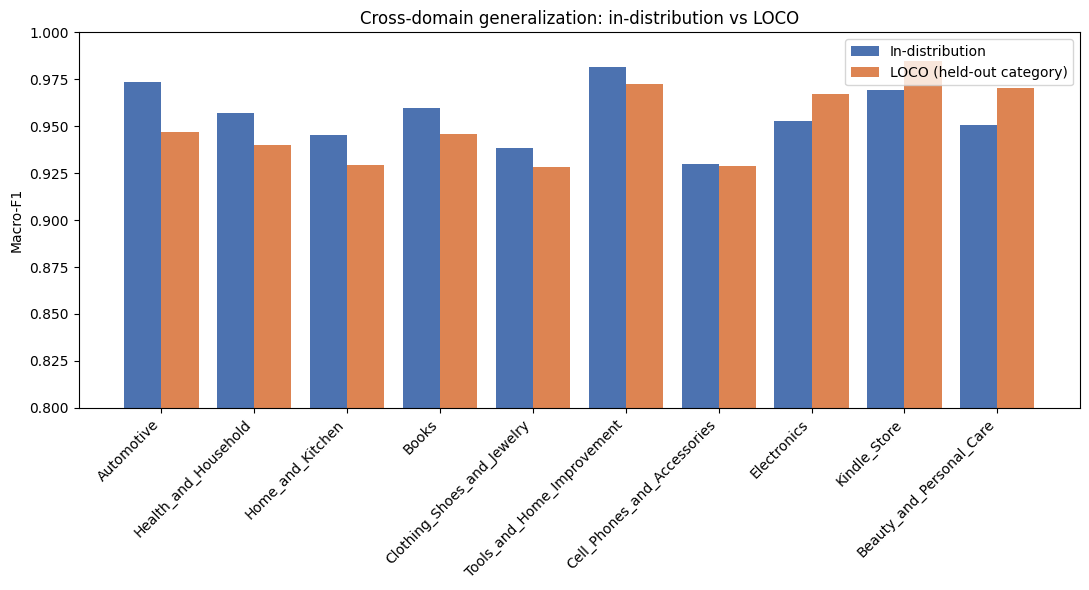

In [23]:
# --- Generalization-gap figure ---
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(merged))
ax.bar(x - 0.2, merged["in_distribution_f1"], width=0.4,
       label="In-distribution", color="#4C72B0")
ax.bar(x + 0.2, merged["loco_f1"], width=0.4,
       label="LOCO (held-out category)", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(merged["category"], rotation=45, ha="right")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0.8, 1.0)   # zoomed: all values are high; this makes gaps visible
ax.set_title("Cross-domain generalization: in-distribution vs LOCO")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "generalization_gap.png", dpi=200, bbox_inches="tight")
plt.show()

Pearson r (n_train vs LOCO macro-F1) = 0.513


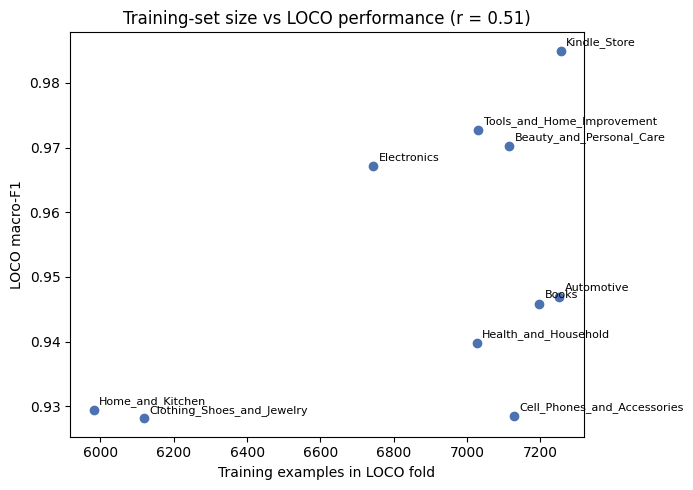

In [24]:
# --- Does training-set size explain LOCO performance? ---
# Pearson correlation between the number of training examples available in a
# LOCO fold and that fold's macro-F1. A strong positive correlation supports
# the interpretation that data quantity, not domain identity, drives the gap.
corr = loco_df["n_train"].corr(loco_df["macro_f1"])
print(f"Pearson r (n_train vs LOCO macro-F1) = {corr:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(loco_df["n_train"], loco_df["macro_f1"], color="#4C72B0")
for _, row in loco_df.iterrows():
    ax.annotate(row["held_out_category"], (row["n_train"], row["macro_f1"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Training examples in LOCO fold")
ax.set_ylabel("LOCO macro-F1")
ax.set_title(f"Training-set size vs LOCO performance (r = {corr:.2f})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "loco_size_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Error analysis

Quantitative (confusion matrices) and qualitative (inspection of misclassified
reviews) error analysis on the headline model. The qualitative sample is
exported so concrete error patterns can be described in the paper's Discussion.

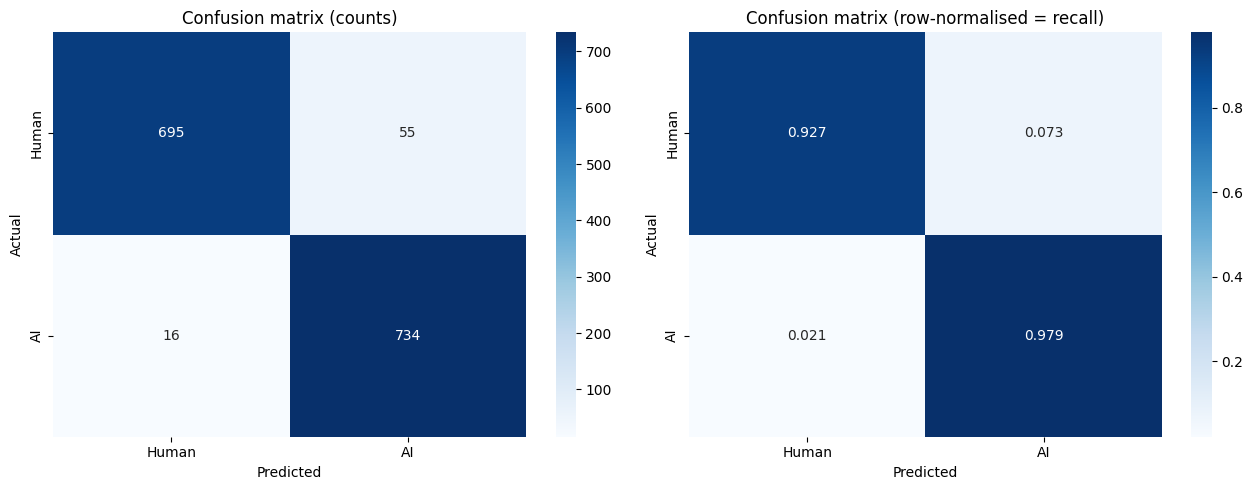


Classification report (test set):
              precision    recall  f1-score   support

       human       0.98      0.93      0.95       750
          ai       0.93      0.98      0.95       750

    accuracy                           0.95      1500
   macro avg       0.95      0.95      0.95      1500
weighted avg       0.95      0.95      0.95      1500



In [25]:
# --- Confusion matrices: raw counts and row-normalised ---
pred_out = headline_trainer.predict(prep_dataset(df_test))
y_pred = np.argmax(pred_out.predictions, axis=-1)
y_true = pred_out.label_ids

cm = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ["Human", "AI"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues", ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title("Confusion matrix (row-normalised = recall)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nClassification report (test set):")
print(classification_report(y_true, y_pred, target_names=["human", "ai"]))

In [27]:
# --- Qualitative inspection of misclassified reviews ---
# Exported for the Discussion section: read these to identify concrete error
# patterns (e.g. 'false positives are short, generically positive human
# reviews'). Such patterns turn a results section into an insightful one.
test_eval = df_test.reset_index(drop=True).copy()
test_eval["pred"] = y_pred
test_eval["correct"] = test_eval["pred"] == test_eval["ai_generated"]
test_eval["n_tokens"] = test_eval["text"].astype(str).str.split().str.len()

errors = test_eval[~test_eval["correct"]].copy()
fp = errors[errors["ai_generated"] == 0]   # human wrongly flagged as AI
fn = errors[errors["ai_generated"] == 1]   # AI wrongly accepted as human
print(f"Misclassified: {len(errors)} total -> "
      f"{len(fp)} false positives (human->AI), "
      f"{len(fn)} false negatives (AI->human)")
print(f"Mean length  -> false positives: {fp['n_tokens'].mean():.1f} tokens, "
      f"false negatives: {fn['n_tokens'].mean():.1f} tokens, "
      f"correct: {test_eval[test_eval['correct']]['n_tokens'].mean():.1f} tokens")

# Export a readable sample for manual inspection.
sample_cols = ["category", "rating", "n_tokens", "ai_generated", "pred", "text"]
err_sample = errors.sample(min(50, len(errors)), random_state=GLOBAL_SEED)
err_sample[sample_cols].to_csv(RESULTS_DIR / "error_sample.csv", index=False)
display(err_sample[sample_cols].head(25))

Misclassified: 71 total -> 55 false positives (human->AI), 16 false negatives (AI->human)
Mean length  -> false positives: 19.4 tokens, false negatives: 9.8 tokens, correct: 31.0 tokens


,category,rating,n_tokens,ai_generated,pred,text
546,Clothing_Shoes_and_Jewelry,5,5,0,1,I love everything about them.
6,Health_and_Household,5,6,1,0,"Love this oil, helps me sleep."
1062,Clothing_Shoes_and_Jewelry,5,24,0,1,I love the shirt and it's perfect for summer w...
82,Electronics,2,38,0,1,"Decent little fan, except the cable is WAY too..."
1193,Home_and_Kitchen,5,18,0,1,Nice shoe rack for the money. Low profile for ...
390,Clothing_Shoes_and_Jewelry,3,28,1,0,"I like the cushioning and the weight, but they..."
251,Electronics,5,10,1,0,These are great for the price. Really happy wi...
743,Home_and_Kitchen,2,6,0,1,Extremely sheer and poor quality material.
968,Home_and_Kitchen,2,5,0,1,but it's 80% as nice.
290,Cell_Phones_and_Accessories,5,13,0,1,I've had this for a month now and it works gre...


## 9. Length-controlled robustness check

The EDA showed AI reviews occupy a narrower length range than human reviews.
This raises the question of whether the detector relies on **review length**
rather than **writing style**.

Two checks are run on the headline model:

1. **Length-stratified evaluation** — macro-F1 within token-length bands. Bands
   where *both* classes are well represented are the informative ones: strong
   performance there means the model discriminates within a fixed length range.
2. **Length-matched evaluation** — within each band, equal numbers of human and
   AI reviews are sampled, so the length distribution is identical for both
   classes. If performance stays high, length cannot be the explanation.

This is a stricter test than simply reporting the confound, and converts a
potential weakness into a documented robustness result.

In [ ]:
# --- 9.1 Length-stratified evaluation ---
bins   = [0, 15, 25, 40, 70, 10_000]
blabels = ["1-15", "16-25", "26-40", "41-70", "70+"]
test_eval["len_bin"] = pd.cut(test_eval["n_tokens"], bins=bins, labels=blabels)

strat_rows = []
for b in blabels:
    sub = test_eval[test_eval["len_bin"] == b]
    if len(sub) < 20:                       # skip bands too small to be reliable
        continue
    n_h = int((sub["ai_generated"] == 0).sum())
    n_a = int((sub["ai_generated"] == 1).sum())
    strat_rows.append({"len_bin": b, "n": len(sub), "n_human": n_h, "n_ai": n_a,
                       **predict_on_df(headline_trainer, sub)})

strat_df = pd.DataFrame(strat_rows)
strat_df.to_csv(RESULTS_DIR / "length_stratified.csv", index=False)
display(strat_df[["len_bin", "n", "n_human", "n_ai", "macro_f1",
                  "recall_human", "recall_ai"]].round(3))
print("Informative bands are those with both n_human and n_ai sizeable. "
      "High macro-F1 there indicates discrimination is not purely length-based.")

Map:   0%|          | 0/495 [00:00<?, ? examples/s]

Map:   0%|          | 0/379 [00:00<?, ? examples/s]

Map:   0%|          | 0/365 [00:00<?, ? examples/s]

Map:   0%|          | 0/163 [00:00<?, ? examples/s]

Map:   0%|          | 0/98 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,len_bin,n,n_human,n_ai,macro_f1,recall_human,recall_ai
0,1-15,495,273,222,0.925,0.890,0.968
1,16-25,379,123,256,0.954,0.894,0.992
2,26-40,365,134,231,0.958,0.903,0.996
3,41-70,163,122,41,0.961,0.959,1.000
4,70+,98,98,0,1.000,1.000,0.000


Informative bands are those with both n_human and n_ai sizeable. High macro-F1 there indicates discrimination is not purely length-based.


In [ ]:
# --- 9.2 Length-matched evaluation ---
# Within each length band, sample an equal number of human and AI reviews so
# the two classes share an identical length distribution.
matched_parts = []
for b in blabels:
    sub = test_eval[test_eval["len_bin"] == b]
    h = sub[sub["ai_generated"] == 0]
    a = sub[sub["ai_generated"] == 1]
    k = min(len(h), len(a))
    if k < 5:                               # band lacks one class -> skip
        continue
    matched_parts.append(h.sample(k, random_state=GLOBAL_SEED))
    matched_parts.append(a.sample(k, random_state=GLOBAL_SEED))

matched = pd.concat(matched_parts).reset_index(drop=True)
print(f"Length-matched subset: {len(matched)} reviews "
      f"({(matched["ai_generated"] == 0).sum()} human / "
      f"{(matched["ai_generated"] == 1).sum()} AI), "
      f"identical length distribution per class.")

matched_metrics = predict_on_df(headline_trainer, matched)
display(pd.DataFrame([matched_metrics]).round(3).T.rename(columns={0: "value"}))

print("\nIf macro-F1 here is close to the headline result, the detector relies "
      "on writing style rather than review length.")

Length-matched subset: 1040 reviews (520 human / 520 AI), identical length distribution per class.


Map:   0%|          | 0/1040 [00:00<?, ? examples/s]

,value
accuracy,0.943
macro_f1,0.943
macro_precision,0.946
macro_recall,0.943
roc_auc,0.990
precision_human,0.981
recall_human,0.904
f1_human,0.941
precision_ai,0.911
recall_ai,0.983



If macro-F1 here is close to the headline result, the detector relies on writing style rather than review length.


## 10. Results summary

The CSV files written to `results/` provide every number and figure needed for
the DistilBERT sections of the paper:

| File | Contents | Paper element |
|---|---|---|
| `headline_summary.csv` | In-distribution mean ± std (3 seeds) | Main results table |
| `per_category_in_distribution.csv` | Per-category in-distribution metrics | Results / appendix |
| `loco_results.csv` | LOCO cross-domain metrics | Main results table |
| `generalization_comparison.csv` | In-distribution vs LOCO gap | Key finding |
| `length_stratified.csv` | Macro-F1 by length band | Robustness check |
| `error_sample.csv` | 50 misclassified reviews | Discussion (qualitative) |
| `*.png` | All figures | Figures |

**Interpretation checklist for the writeup**
1. Headline in-distribution macro-F1 with seed variance.
2. LOCO range across categories — is the gap small or large?
3. Sign and size of the `n_train` vs LOCO-F1 correlation — data quantity vs domain shift.
4. Per-class recall in skewed LOCO folds — symmetric drop vs one-sided (prior shift).
5. False-positive vs false-negative balance from the confusion matrix.
6. Length-matched macro-F1 vs headline — style vs length.

- Decide as a team whether to enable `APPLY_TEXT_CLEANING` (must be consistent
  across all models).


In [ ]:
# ============================================================
# Section 11 — Calibration analysis
# ------------------------------------------------------------
# Motivation: the LOCO results showed PRIOR SHIFT — when a held-out
# category's class balance differs from training, the model leans toward
# the majority class. This section quantifies the model's calibration
# (do its confidence scores match actual accuracy?) and shows how a
# class-balanced decision threshold corrects the prior-shift effect.
#
# No retraining: this reuses the headline model from Section 4.
# ============================================================

def get_probs(trainer, df):
    """Return (true labels, predicted P(AI)) for a dataframe slice."""
    out = trainer.predict(prep_dataset(df))
    probs = torch.softmax(torch.from_numpy(out.predictions), dim=-1)[:, 1].numpy()
    return out.label_ids, probs


def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Expected Calibration Error (ECE).
    Bins predictions by confidence; in each bin compares mean confidence
    against actual accuracy. ECE is the sample-weighted average gap.
    A perfectly calibrated model has ECE = 0."""
    # Confidence = probability assigned to the PREDICTED class.
    y_pred = (y_prob >= 0.5).astype(int)
    confidence = np.where(y_pred == 1, y_prob, 1 - y_prob)
    correct = (y_pred == y_true).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        # Last bin is inclusive of 1.0
        in_bin = (confidence > lo) & (confidence <= hi) if hi < 1.0 \
                 else (confidence > lo) & (confidence <= hi + 1e-9)
        n = in_bin.sum()
        if n == 0:
            rows.append({"bin_lo": lo, "bin_hi": hi, "n": 0,
                         "avg_confidence": np.nan, "accuracy": np.nan})
            continue
        avg_conf = confidence[in_bin].mean()
        acc      = correct[in_bin].mean()
        ece     += (n / len(y_true)) * abs(avg_conf - acc)
        rows.append({"bin_lo": lo, "bin_hi": hi, "n": int(n),
                     "avg_confidence": avg_conf, "accuracy": acc})
    return ece, pd.DataFrame(rows)


# --- Compute calibration on the held-out test set (headline model) ---
y_true_cal, y_prob_cal = get_probs(headline_trainer, df_test)
ece, bin_df = expected_calibration_error(y_true_cal, y_prob_cal, n_bins=10)
print(f"Expected Calibration Error (test set): {ece:.4f}")
display(bin_df.round(3))

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Expected Calibration Error (test set): 0.0359


,bin_lo,bin_hi,n,avg_confidence,accuracy
0,0.0,0.1,0,NaN,NaN
1,0.1,0.2,0,NaN,NaN
2,0.2,0.3,0,NaN,NaN
3,0.3,0.4,0,NaN,NaN
4,0.4,0.5,0,NaN,NaN
5,0.5,0.6,7,0.550,0.429
6,0.6,0.7,12,0.644,0.500
7,0.7,0.8,10,0.750,0.300
8,0.8,0.9,18,0.859,0.611
9,0.9,1.0,1453,0.997,0.968


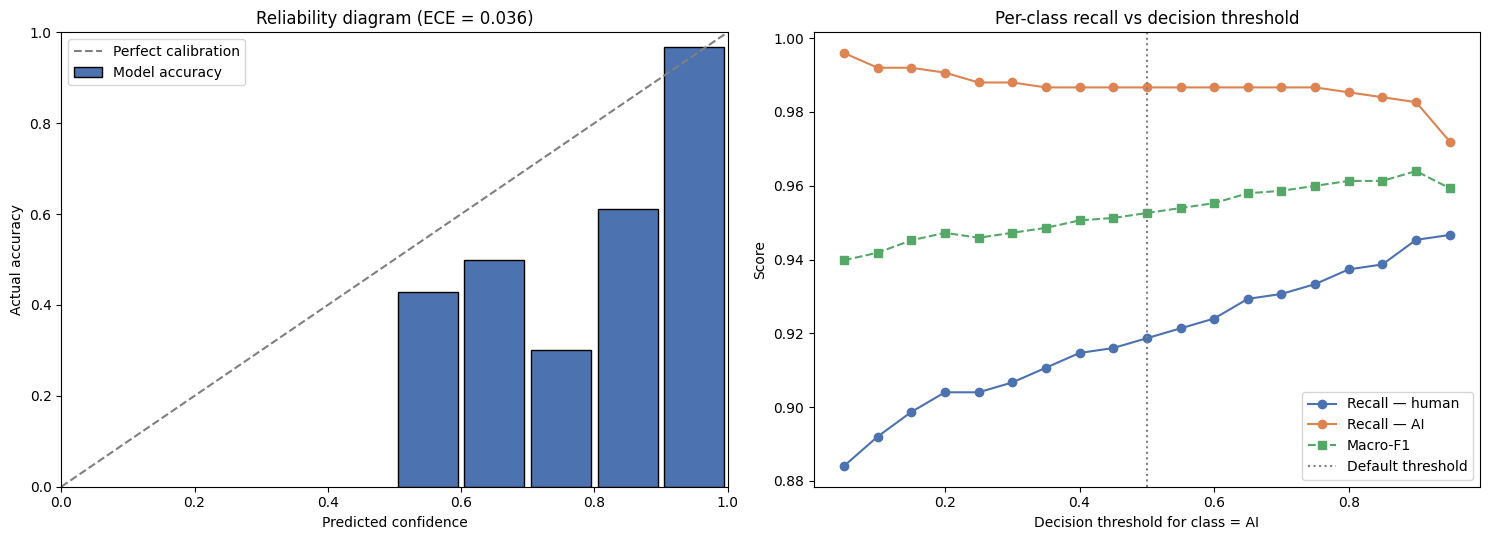

Macro-F1 is maximised at threshold = 0.90 (macro-F1 = 0.964), vs the default 0.50.
If the optimum is far from 0.50, the model's scores are biased and a tuned threshold meaningfully improves the class balance — this is the prior-shift effect made concrete.


In [ ]:
# ============================================================
# Section 11 (cont.) — Reliability diagram + threshold analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- 11.1 Reliability diagram ---
# Plots accuracy vs confidence per bin. The diagonal is perfect calibration;
# bars below it = overconfidence, above it = underconfidence.
valid = bin_df.dropna(subset=["accuracy"])
bin_centers = (valid["bin_lo"] + valid["bin_hi"]) / 2
axes[0].bar(bin_centers, valid["accuracy"], width=0.09,
            edgecolor="black", color="#4C72B0", label="Model accuracy")
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Perfect calibration")
axes[0].set_xlabel("Predicted confidence")
axes[0].set_ylabel("Actual accuracy")
axes[0].set_title(f"Reliability diagram (ECE = {ece:.3f})")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].legend()

# --- 11.2 Threshold sweep: per-class recall vs decision threshold ---
# The default threshold is 0.5. Because the test set / LOCO folds can be
# class-imbalanced, sweeping the threshold shows the precision-recall
# trade-off and lets us find a balance point.
thresholds = np.linspace(0.05, 0.95, 19)
sweep_rows = []
for t in thresholds:
    y_pred_t = (y_prob_cal >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true_cal, y_pred_t, labels=[0, 1], zero_division=0)
    sweep_rows.append({"threshold": t,
                       "recall_human": r[0], "recall_ai": r[1],
                       "f1_human": f1[0], "f1_ai": f1[1],
                       "macro_f1": (f1[0] + f1[1]) / 2})
sweep_df = pd.DataFrame(sweep_rows)

axes[1].plot(sweep_df["threshold"], sweep_df["recall_human"],
             marker="o", label="Recall — human", color="#4C72B0")
axes[1].plot(sweep_df["threshold"], sweep_df["recall_ai"],
             marker="o", label="Recall — AI", color="#DD8452")
axes[1].plot(sweep_df["threshold"], sweep_df["macro_f1"],
             marker="s", linestyle="--", label="Macro-F1", color="#55A868")
axes[1].axvline(0.5, color="grey", linestyle=":", label="Default threshold")
axes[1].set_xlabel("Decision threshold for class = AI")
axes[1].set_ylabel("Score")
axes[1].set_title("Per-class recall vs decision threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "calibration_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Threshold that maximises macro-F1 ---
best = sweep_df.loc[sweep_df["macro_f1"].idxmax()]
print(f"Macro-F1 is maximised at threshold = {best['threshold']:.2f} "
      f"(macro-F1 = {best['macro_f1']:.3f}), vs the default 0.50.")
print("If the optimum is far from 0.50, the model's scores are biased and a "
      "tuned threshold meaningfully improves the class balance — this is the "
      "prior-shift effect made concrete.")

sweep_df.to_csv(RESULTS_DIR / "threshold_sweep.csv", index=False)
bin_df.to_csv(RESULTS_DIR / "calibration_bins.csv", index=False)

In [ ]:
# ============================================================
# Section 12 — Threshold sweep on a skewed LOCO fold
# ------------------------------------------------------------
# Motivation: the in-distribution test set is balanced (50/50), so there is
# no class prior to "shift". Prior shift only appears when the deployment
# distribution differs from training. The LOCO folds ARE such a case:
# e.g. the Kindle_Store test slice is ~73% AI.
#
# This section retrains ONE LOCO fold on a skewed held-out category and
# sweeps the decision threshold on it, showing that the threshold that
# balances the two classes moves away from 0.50 — the prior-shift effect
# made concrete, in the setting where it actually occurs.
# ============================================================

# Pick the most skewed held-out category from the LOCO results.
# (Kindle_Store had ~73% AI in test; confirm against loco_df.)
SKEW_CATEGORY = loco_df.sort_values("pct_ai_in_test").iloc[-1]["held_out_category"]
print(f"Most AI-skewed LOCO fold: {SKEW_CATEGORY} "
      f"(test set {loco_df.set_index('held_out_category').loc[SKEW_CATEGORY, 'pct_ai_in_test']:.0%} AI)")

# Rebuild that fold exactly as Section 6 did: train on the 9 OTHER categories.
pool_skew = df_pool[df_pool["category"] != SKEW_CATEGORY].reset_index(drop=True)
tr_skew, va_skew = train_test_split(
    pool_skew, test_size=0.10, stratify=pool_skew["ai_generated"],
    random_state=GLOBAL_SEED)
te_skew = df_test[df_test["category"] == SKEW_CATEGORY].reset_index(drop=True)

skew_trainer = train_one(tr_skew, va_skew, MODELS_DIR / "skew_fold_tmp",
                         seed=GLOBAL_SEED)

Most AI-skewed LOCO fold: Kindle_Store (test set 73% AI)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/7255 [00:00<?, ? examples/s]

Map:   0%|          | 0/807 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.02828', 'grad_norm': '0.5886', 'learning_rate': '6.065e-06', 'epoch': '2.093'}
{'loss': '0.03795', 'grad_norm': '0.01175', 'learning_rate': '5.33e-06', 'epoch': '2.203'}
{'loss': '0.01272', 'grad_norm': '0.03761', 'learning_rate': '4.596e-06', 'epoch': '2.313'}
{'loss': '0.02144', 'grad_norm': '0.1676', 'learning_rate': '3.862e-06', 'epoch': '2.423'}
{'loss': '0.04557', 'grad_norm': '0.3631', 'learning_rate': '3.128e-06', 'epoch': '2.533'}
{'loss': '0.06204', 'grad_norm': '2.694', 'learning_rate': '2.394e-06', 'epoch': '2.643'}
{'loss': '0.04967', 'grad_norm': '0.01904', 'learning_rate': '1.659e-06', 'epoch': '2.753'}
{'loss': '0.04171', 'grad_norm': '4.556', 'learning_rate': '9.251e-07', 'epoch': '2.863'}
{'loss': '0.01893', 'grad_norm': '0.0188', 'learning_rate': '1.909e-07', 'epoch': '2.974'}
{'eval_loss': '0.1689', 'eval_accuracy': '0.9566', 'eval_macro_f1': '0.9566', 'eval_macro_precision': '0.9574', 'eval_macro_recall': '0.9572', 'eval_roc_auc': '0.9963', 'eval_runtim

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


{'train_runtime': '123.6', 'train_samples_per_second': '176.1', 'train_steps_per_second': '11.02', 'train_loss': '0.116', 'epoch': '3'}


Map:   0%|          | 0/86 [00:00<?, ? examples/s]

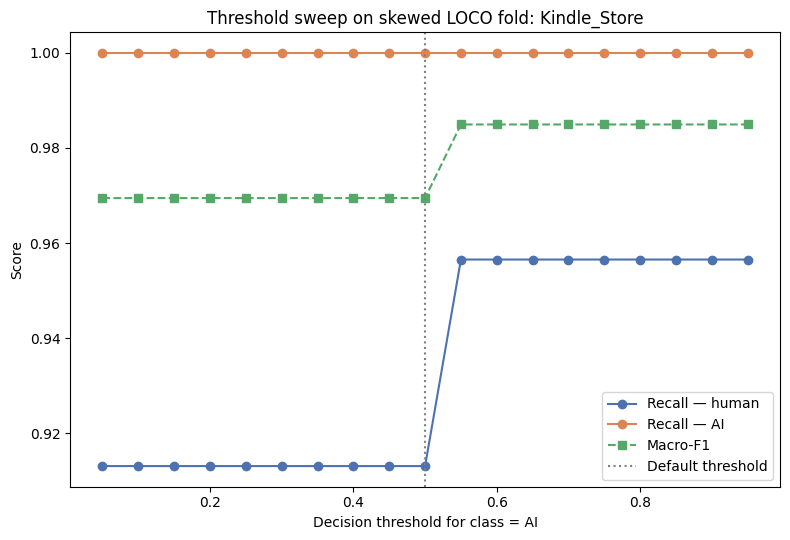


--- Kindle_Store (skewed LOCO fold) ---
At default 0.50 : macro-F1 0.969, recall_human 0.913, recall_ai 1.000
Macro-F1 optimum: threshold 0.55, macro-F1 0.985
Recall-balance  : threshold 0.55 (human/AI recall closest)

Compare the optimum/balance threshold here against the balanced test set (Section 11). A larger departure from 0.50 on this skewed fold is the prior-shift effect.


In [ ]:
# ============================================================
# Section 12 (cont.) — Sweep and compare to the balanced test set
# ============================================================

# Predicted P(AI) on the skewed held-out category.
y_true_skew, y_prob_skew = get_probs(skew_trainer, te_skew)

# Same threshold grid as Section 11, so the two sweeps are comparable.
thresholds = np.linspace(0.05, 0.95, 19)
skew_rows = []
for t in thresholds:
    y_pred_t = (y_prob_skew >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true_skew, y_pred_t, labels=[0, 1], zero_division=0)
    skew_rows.append({"threshold": t,
                      "recall_human": r[0], "recall_ai": r[1],
                      "f1_human": f1[0], "f1_ai": f1[1],
                      "macro_f1": (f1[0] + f1[1]) / 2})
skew_sweep = pd.DataFrame(skew_rows)
skew_sweep.to_csv(RESULTS_DIR / "threshold_sweep_loco_skewed.csv", index=False)

# --- Figure: skewed-fold sweep ---
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(skew_sweep["threshold"], skew_sweep["recall_human"],
        marker="o", label="Recall — human", color="#4C72B0")
ax.plot(skew_sweep["threshold"], skew_sweep["recall_ai"],
        marker="o", label="Recall — AI", color="#DD8452")
ax.plot(skew_sweep["threshold"], skew_sweep["macro_f1"],
        marker="s", linestyle="--", label="Macro-F1", color="#55A868")
ax.axvline(0.5, color="grey", linestyle=":", label="Default threshold")
ax.set_xlabel("Decision threshold for class = AI")
ax.set_ylabel("Score")
ax.set_title(f"Threshold sweep on skewed LOCO fold: {SKEW_CATEGORY}")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "threshold_sweep_loco_skewed.png",
            dpi=200, bbox_inches="tight")
plt.show()

# --- Quantify the prior-shift effect ---
default_row = skew_sweep.iloc[(skew_sweep["threshold"] - 0.5).abs().idxmin()]
best_row    = skew_sweep.loc[skew_sweep["macro_f1"].idxmax()]

# The "balance point": threshold where the two class recalls are closest.
skew_sweep["recall_gap"] = (skew_sweep["recall_human"]
                            - skew_sweep["recall_ai"]).abs()
balance_row = skew_sweep.loc[skew_sweep["recall_gap"].idxmin()]

print(f"\n--- {SKEW_CATEGORY} (skewed LOCO fold) ---")
print(f"At default 0.50 : macro-F1 {default_row['macro_f1']:.3f}, "
      f"recall_human {default_row['recall_human']:.3f}, "
      f"recall_ai {default_row['recall_ai']:.3f}")
print(f"Macro-F1 optimum: threshold {best_row['threshold']:.2f}, "
      f"macro-F1 {best_row['macro_f1']:.3f}")
print(f"Recall-balance  : threshold {balance_row['threshold']:.2f} "
      f"(human/AI recall closest)")
print("\nCompare the optimum/balance threshold here against the balanced "
      "test set (Section 11). A larger departure from 0.50 on this skewed "
      "fold is the prior-shift effect.")

free_memory(skew_trainer)